# HW1 — Monte Carlo

**Course:** Reinforcement Learning — IE University Madrid

**Instructor:** Jaume Manero

**Author:** Elad Moshe

**Program:** MCSBT

**Date:** May 2026

---

### Notebooks Structure

1. Activity 1 — Familiarisation with Gymnasium Environments
2. Activity 2 — Monte Carlo on FrozenLake 4×4 and 8×8
3. **Activity 3 — Monte Carlo on Volcano**
4. Activity 4 — Monte Carlo on Taxi
5. Activity 5 — TD(0) on FrozenLake
6. Questions

---

> **AI Usage Disclaimer:** This notebook was developed with AI assistance (Claude, Anthropic). AI was used to improve documentation and markdown explanations, help structure the notebook, and assist with debugging implementation code. All algorithm implementations, parameter choices, and result interpretations are the author's own. As required by the course AI policy, care was taken to understand every critical update step.

In [1]:
!pip install gymnasium

In [2]:
import sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print(f"Python    : {sys.version.split()[0]}")
print(f"gymnasium : {gym.__version__}")
print(f"numpy     : {np.__version__}")

Python    : 3.13.13
gymnasium : 1.3.0
numpy     : 2.4.4


In [3]:
# ── Helper Functions (shared with Activity 2) ──────────────────────────────────

def run_episode(env, Q, epsilon, max_steps=1000):
    """Run one episode under epsilon-greedy policy.
    Returns list of (state, action, reward) tuples."""
    state, _ = env.reset()
    episode = []
    for _ in range(max_steps):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode


def mc_control(env, n_episodes, alpha, gamma, eps_start, eps_decay, eps_min,
               Q_init=0.0, linear_eps=False, max_steps=1000):
    """Every-Visit MC Control with epsilon-greedy exploration and epsilon decay.

    Q_init     : initial value for all Q entries (0.0 = standard; >0 = optimistic init).
    linear_eps : if True, epsilon decays linearly from eps_start to eps_min over
                 n_episodes.  eps_decay is ignored.
                 if False (default), epsilon decays multiplicatively each episode.
    max_steps  : maximum steps per episode.  Use a small value (e.g. 30) to prevent
                 long wandering episodes that produce noisy G estimates in every-visit MC.
    Returns the learned Q-table and a per-episode win log (1=reached goal, 0=not)."""
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q       = np.full((n_states, n_actions), float(Q_init))
    epsilon = eps_start
    wins    = []

    for ep in range(n_episodes):
        if linear_eps:
            epsilon = max(eps_min, eps_start - (eps_start - eps_min) * (ep / n_episodes))

        episode = run_episode(env, Q, epsilon, max_steps=max_steps)

        # ── Critical step: walk episode backwards, compute G_t, update Q
        G = 0.0
        for state, action, reward in reversed(episode):
            G = reward + gamma * G                          # discounted return
            Q[state, action] += alpha * (G - Q[state, action])  # MC update rule

        if not linear_eps:
            epsilon = max(eps_min, epsilon * eps_decay)

        wins.append(1 if episode[-1][2] > 0 else 0)

    return Q, wins


def smooth(values, window):
    """Rolling mean with given window size."""
    return np.convolve(values, np.ones(window) / window, mode='valid')

---
<a id="activity-3"></a>
## Activity 3 — Monte Carlo Control on Volcano

The Volcano environment is a custom 3×4 gridworld from the course GitHub. The agent starts at **S** and must navigate to a positive terminal state while avoiding the lava.

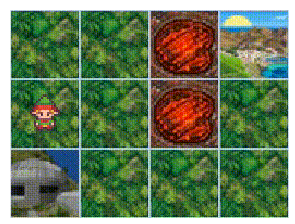

---

### Grid Layout

```
 Col:  0    1    2    3
Row 0: .    .    L    V
Row 1: S    .    L    .
Row 2: G    .    .    .
```

| Cell | Symbol | Reward | Terminal? |
|------|--------|--------|-----------|
| Empty | `.` | 0 | No |
| Start | `S` | 0 | No |
| Lava | `L` | −50 | **Yes** |
| View | `V` | +20 | **Yes** |
| Goal | `G` | +2 | **Yes** |

- **State space** — `Discrete(12)`: `state = row × 4 + col`
- **Action space** — `Discrete(4)`: 0=North, 1=East, 2=South, 3=West
- **Reward** — sparse and asymmetric: reaching the scenic **Viewpoint** (+20) is far more valuable than the safe **Goal** (+2); falling into **Lava** is catastrophic (−50)

---

### What's Different from FrozenLake?

| Feature | FrozenLake | Volcano |
|---------|-----------|---------|
| Grid size | 4×4 or 8×8 | 3×4 |
| Negative reward | None (0 on hole) | −50 on lava |
| Multiple goals | No | Yes (View +20, Goal +2) |
| Reward shaping | Binary (0/+1) | Three levels |

The negative lava reward means Q-values can go strongly negative, forcing the agent to actively **avoid** bad regions rather than just drift toward the goal. This is a richer signal than FrozenLake's zero-reward holes.

In [4]:
# ── Activity 3 — Cell 1: Setup — Download & Import Volcano Environment ──────────
# The Volcano environment is a custom Gymnasium env from the course GitHub repo.
# We download the two source files once if they are not already present locally.

import os, urllib.request

VOLCANO_DIR = "volcano_rl"
BASE_URL    = "https://raw.githubusercontent.com/castorgit/RL_course/main/volcano_rl"

if not os.path.isdir(VOLCANO_DIR):
    os.makedirs(VOLCANO_DIR)
    for fname in ("__init__.py", "volcano_world.py"):
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}",
                                   os.path.join(VOLCANO_DIR, fname))
    print(f"Downloaded volcano_rl → ./{VOLCANO_DIR}/")
else:
    print(f"volcano_rl already present at ./{VOLCANO_DIR}/")

from volcano_rl import VolcanoWorldEnv, register_env
register_env()
print("Registered environment: 'VolcanoWorld-v0'")

volcano_rl already present at ./volcano_rl/
Registered environment: 'VolcanoWorld-v0'


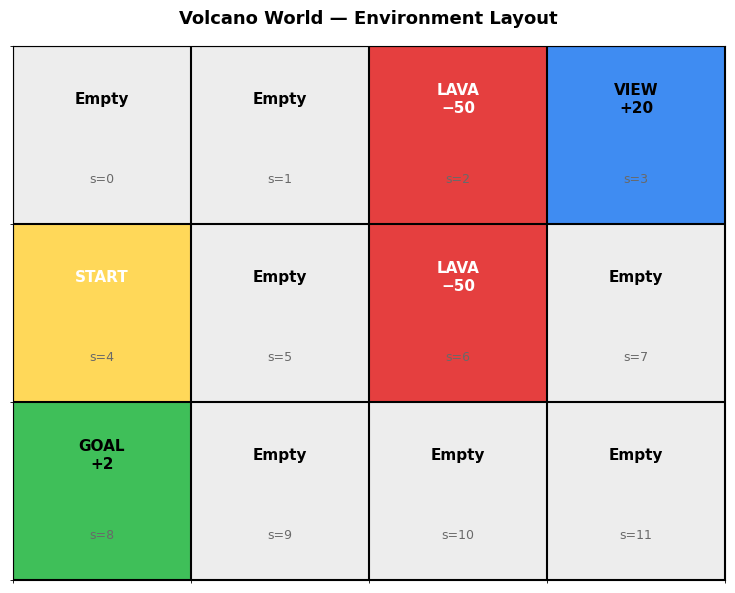

In [5]:
CELL_BG = {
    ".": [0.93, 0.93, 0.93],
    "S": [1.00, 0.85, 0.35],
    "L": [0.90, 0.25, 0.25],
    "V": [0.25, 0.55, 0.95],
    "G": [0.25, 0.75, 0.35],
}

# ── Activity 3 — Visualise Volcano Environment Grid ────────────────────────

env_v_viz = VolcanoWorldEnv(is_slippery=False)

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Volcano World — Environment Layout", fontsize=13, fontweight='bold')

nrow, ncol = env_v_viz.nrow, env_v_viz.ncol
desc = env_v_viz.desc

# Create background color grid
bg = np.array([[CELL_BG[desc[r, c]] for c in range(ncol)] for r in range(nrow)])
ax.imshow(bg, interpolation='nearest')

# Add cell labels and state indices
CELL_INFO = {
    "S": ("START", "white"),
    "L": ("LAVA\n−50", "white"),
    "V": ("VIEW\n+20", "black"),
    "G": ("GOAL\n+2", "black"),
    ".": ("Empty", "black"),
}

for r in range(nrow):
    for c in range(ncol):
        sym = desc[r, c]
        s = env_v_viz.to_s(r, c)
        
        # Cell label
        label, text_color = CELL_INFO[sym]
        ax.text(c, r - 0.2, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)
        
        # State index
        ax.text(c, r + 0.25, f"s={s}", ha='center', va='center',
                fontsize=9, color='dimgray')

ax.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
ax.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.5, ncol - 0.5)
ax.set_ylim(nrow - 0.5, -0.5)

plt.tight_layout()
plt.show()

env_v_viz.close()

In [6]:
# ── Activity 3 — Cell 2: Explore the Volcano Environment ─────────────────────


env_v = VolcanoWorldEnv(is_slippery=False)
obs, _ = env_v.reset(seed=0)

VOLCANO_ACTIONS = {0: "North (↑)", 1: "East (→)", 2: "South (↓)", 3: "West (←)"}

print("=== Volcano World — Environment Description ===\n")
print(f"  Grid size         : {env_v.nrow} rows × {env_v.ncol} cols")
print(f"  Observation space : Discrete({env_v.observation_space.n})"
      f"  [state = row × {env_v.ncol} + col]")
print(f"  Action space      : Discrete({env_v.action_space.n})")
for a, label in VOLCANO_ACTIONS.items():
    print(f"    Action {a} = {label}")
print()

# Print grid with state indices so we can cross-reference Q-table rows later
print("  Grid layout (symbol | state index):")
for r in range(env_v.nrow):
    row_str = "  "
    for c in range(env_v.ncol):
        s   = env_v.to_s(r, c)
        sym = env_v.desc[r, c]
        row_str += f"  {sym}({s:>2})"
    print(row_str)

print()
print("  Cell types & rewards:")
print("    '.'  Empty : reward=  0, terminal=False")
print("    'S'  Start : reward=  0, terminal=False  ← initial position")
print("    'L'  Lava  : reward=-50, terminal=True   ← catastrophic")
print("    'V'  View  : reward=+20, terminal=True   ← best outcome")
print("    'G'  Goal  : reward= +2, terminal=True   ← safe exit")
print()

# Show all transitions from the start state
start_s = env_v.to_s(1, 0)   # row=1, col=0  → state 4
print(f"  Transitions from Start (state {start_s}) — non-slippery:")
for a, label in VOLCANO_ACTIONS.items():
    for prob, next_s, rew, done in env_v.P[start_s][a]:
        nr, nc = env_v.from_s(next_s)
        sym    = env_v.desc[nr, nc]
        print(f"    {label:>12} → state {next_s:>2} ({sym})  reward={rew:>5}  terminal={done}")

env_v.close()

=== Volcano World — Environment Description ===

  Grid size         : 3 rows × 4 cols
  Observation space : Discrete(12)  [state = row × 4 + col]
  Action space      : Discrete(4)
    Action 0 = North (↑)
    Action 1 = East (→)
    Action 2 = South (↓)
    Action 3 = West (←)

  Grid layout (symbol | state index):
    .( 0)  .( 1)  L( 2)  V( 3)
    S( 4)  .( 5)  L( 6)  .( 7)
    G( 8)  .( 9)  .(10)  .(11)

  Cell types & rewards:
    '.'  Empty : reward=  0, terminal=False
    'S'  Start : reward=  0, terminal=False  ← initial position
    'L'  Lava  : reward=-50, terminal=True   ← catastrophic
    'V'  View  : reward=+20, terminal=True   ← best outcome
    'G'  Goal  : reward= +2, terminal=True   ← safe exit

  Transitions from Start (state 4) — non-slippery:
       North (↑) → state  0 (.)  reward=  0.0  terminal=False
        East (→) → state  5 (.)  reward=  0.0  terminal=False
       South (↓) → state  8 (G)  reward=  2.0  terminal=True
        West (←) → state  4 (S)  reward=  

In [7]:
# ── Activity 3 — Cell 3: MC Control Training on Volcano ──────────────────────
# We reuse run_episode() and mc_control() defined above unchanged
#   Q[s, a] += alpha * (G_t - Q[s, a])      ← MC prediction error
#
# Root cause of all failures (Trials 1–5):
#   After the last run (Trial 5, 2M eps, linear decay) the Q-table showed that
#   states (1,3) and (2,3) had CORRECT Q-values pointing to View, but the chain
#   broke at (2,2) and (2,1) which both pointed West toward Goal.
#
#   Why? Our run_episode used max_steps=1000.  With 1000 steps allowed, the agent
#   wanders through (2,1) and (2,2) dozens of times per episode, each visit
#   receiving a different G value depending on whatever happens in the remaining
#   ~800 steps.  In every-visit MC, ALL those visits get updated.  The Q[West]
#   at (2,1) is rock-stable (1-step Goal, G=2 always).  Q[East] at (2,1) gets
#   buried under hundreds of noisy cross-visit returns from long wandering episodes
#   and never rises above 2.0.
#
# Fix — max_steps=30:
#   With a 3×4 grid the longest meaningful path is ~10 steps.  Capping at 30 forces short, clean episodes.

# ── Trial 1 — baseline (result: 100% Goal, 0% View) ──────────────────────────
# N_EPISODES_V = 50_000
# ALPHA_V      = 0.05
# GAMMA_V      = 0.99
# EPS_START_V  = 1.0
# EPS_DECAY_V  = 0.9999      # multiplicative — hits 0.05 after ~23k eps
# EPS_MIN_V    = 0.05
# Q_INIT_V     = 0.0
# LINEAR_EPS_V = False
# MAX_STEPS_V  = 1000

# ── Trial 2 — higher alpha, slower decay, more episodes (result: 100% Goal, 0% View) ─
# N_EPISODES_V = 200_000
# ALPHA_V      = 0.15
# GAMMA_V      = 0.99
# EPS_START_V  = 1.0
# EPS_DECAY_V  = 0.99998     # multiplicative — still hits min before 200k
# EPS_MIN_V    = 0.05
# Q_INIT_V     = 0.0
# LINEAR_EPS_V = False
# MAX_STEPS_V  = 1000

# ── Trial 3 — much higher eps_min, even slower decay (result: 100% Goal, 0% View) ───
# N_EPISODES_V = 500_000
# ALPHA_V      = 0.20
# GAMMA_V      = 0.99
# EPS_START_V  = 1.0
# EPS_DECAY_V  = 0.99999     # multiplicative — still collapses too fast
# EPS_MIN_V    = 0.15
# Q_INIT_V     = 0.0
# LINEAR_EPS_V = False
# MAX_STEPS_V  = 1000

# ── Trial 4 — optimistic initialisation (result: 100% Goal, 0% View) ─────────
# N_EPISODES_V = 100_000
# ALPHA_V      = 0.10
# GAMMA_V      = 0.99
# EPS_START_V  = 1.0
# EPS_DECAY_V  = 0.9999
# EPS_MIN_V    = 0.05
# Q_INIT_V     = 20.0        # optimistic init — still max_steps=1000, still fails
# LINEAR_EPS_V = False
# MAX_STEPS_V  = 1000

# ── Trial 5 — linear epsilon decay (result: 100% Goal, 0% View) ──────────────
# N_EPISODES_V = 2_000_000
# ALPHA_V      = 0.01
# GAMMA_V      = 0.99
# EPS_START_V  = 1.0
# EPS_DECAY_V  = None
# EPS_MIN_V    = 0.1
# Q_INIT_V     = 0.0
# LINEAR_EPS_V = True        # correct decay shape — but max_steps=1000 still noisy
# MAX_STEPS_V  = 1000

# ── Trial 6 — linear decay + max_steps=30 (worked!!) ─
N_EPISODES_V = 2_000_000
ALPHA_V      = 0.01
GAMMA_V      = 0.99
EPS_START_V  = 1.0
EPS_DECAY_V  = None          # unused when LINEAR_EPS_V=True
EPS_MIN_V    = 0.1
Q_INIT_V     = 0.0
LINEAR_EPS_V = True          # epsilon = max(0.1, 1.0 - 0.9 * (ep / 2_000_000))
MAX_STEPS_V  = 30            # short episodes = clean G estimates

env_v = VolcanoWorldEnv(is_slippery=False)

print("Training MC Control on Volcano (non-slippery, linear ε, max_steps=30)...")
print(f"  α={ALPHA_V}  γ={GAMMA_V}  ε: {EPS_START_V} → {EPS_MIN_V} (linear over {N_EPISODES_V:,} eps)")
print(f"  Q_init={Q_INIT_V}  max_steps={MAX_STEPS_V}  |  {N_EPISODES_V:,} episodes")

t0 = time.time()

Q_v, wins_v = mc_control(
    env_v, N_EPISODES_V, ALPHA_V, GAMMA_V, EPS_START_V, EPS_DECAY_V, EPS_MIN_V,
    Q_init=Q_INIT_V, linear_eps=LINEAR_EPS_V, max_steps=MAX_STEPS_V,
)

elapsed = time.time() - t0
env_v.close()

print(f"\nDone in {elapsed:.1f}s")
print(f"  Win rate last 1000 eps : {np.mean(wins_v[-1000:]):.1%}  (win = any +reward terminal)")
print(f"  Non-zero Q entries     : {np.count_nonzero(Q_v)} / {Q_v.size}")
print()

ARROWS_V = {0: "↑", 1: "→", 2: "↓", 3: "←"}
env_v2   = VolcanoWorldEnv(is_slippery=False)
print("  Learned Q-table  (↑=North  →=East  ↓=South  ←=West):")
print(f"  {'State':<9}{'Cell':<5}  {'Q[↑]':>7} {'Q[→]':>7} {'Q[↓]':>7} {'Q[←]':>7}  Best")
print("  " + "-"*56)
for r in range(env_v2.nrow):
    for c in range(env_v2.ncol):
        s    = env_v2.to_s(r, c)
        sym  = env_v2.desc[r, c]
        best = ARROWS_V[int(np.argmax(Q_v[s]))]
        print(f"  ({r},{c}) s={s:<2}  {sym:<5}  "
              f"{Q_v[s,0]:>7.2f} {Q_v[s,1]:>7.2f} {Q_v[s,2]:>7.2f} {Q_v[s,3]:>7.2f}  {best}")
env_v2.close()

Training MC Control on Volcano (non-slippery, linear ε, max_steps=30)...
  α=0.01  γ=0.99  ε: 1.0 → 0.1 (linear over 2,000,000 eps)
  Q_init=0.0  max_steps=30  |  2,000,000 episodes

Done in 201.1s
  Win rate last 1000 eps : 92.3%  (win = any +reward terminal)
  Non-zero Q entries     : 32 / 48

  Learned Q-table  (↑=North  →=East  ↓=South  ←=West):
  State    Cell      Q[↑]    Q[→]    Q[↓]    Q[←]  Best
  --------------------------------------------------------
  (0,0) s=0   .         0.80    3.37    8.90    2.28  ↓
  (0,1) s=1   .         4.67  -50.00   12.62    4.24  ↓
  (0,2) s=2   L         0.00    0.00    0.00    0.00  ↑
  (0,3) s=3   V         0.00    0.00    0.00    0.00  ↑
  (1,0) s=4   S         9.08   11.73    2.00    9.08  →
  (1,1) s=5   .        11.01  -50.00   14.13   11.04  ↓
  (1,2) s=6   L         0.00    0.00    0.00    0.00  ↑
  (1,3) s=7   .        20.00   16.94   17.82  -50.00  ↑
  (2,0) s=8   G         0.00    0.00    0.00    0.00  ↑
  (2,1) s=9   .        10.63 

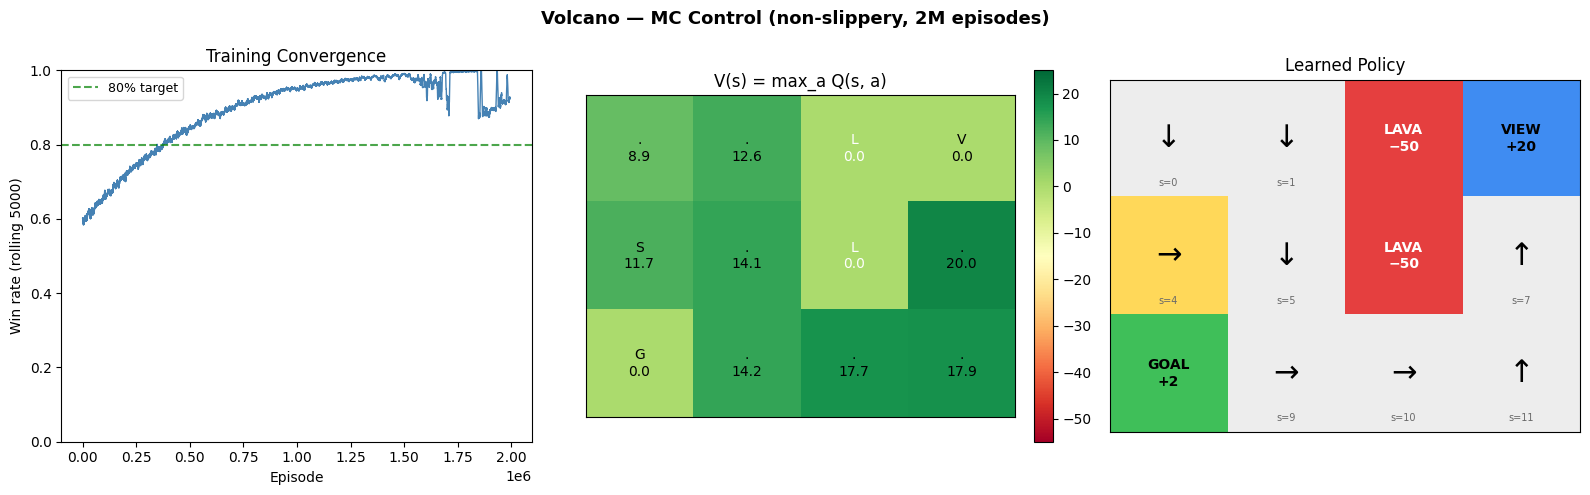

  Final win rate (last 1000 eps) : 92.3%
  Non-zero Q entries             : 32 / 48


In [8]:
# ── Activity 3 — Cell 4: Visualise Training Results ──────────────────────────
# Three-panel figure tailored to the 3×4 Volcano grid:
#   Left   — win-rate convergence curve  (same win definition as Activity 2)
#   Centre — V(s) heatmap  (RdYlGn: red=lava, green=viewpoint)
#   Right  — policy arrows overlaid on the coloured grid

VOLCANO_ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def visualize_volcano(Q, env, wins, title, smooth_window=500):
    nrow, ncol = env.nrow, env.ncol
    desc       = env.desc
    V          = Q.max(axis=1).reshape(nrow, ncol)
    policy     = np.argmax(Q, axis=1).reshape(nrow, ncol)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # ── 1. Convergence curve ──────────────────────────────────────────────────
    ax = axes[0]
    sw = min(smooth_window, len(wins) // 2)
    ax.plot(smooth(wins, sw), color="steelblue", linewidth=1)
    ax.axhline(0.8, color="green", linestyle="--", alpha=0.7, label="80% target")
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Win rate (rolling {sw})")
    ax.set_title("Training Convergence")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    # ── 2. V(s) heatmap ───────────────────────────────────────────────────────
    ax = axes[1]
    im = ax.imshow(V, cmap="RdYlGn", interpolation="nearest", vmin=-55, vmax=25)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(nrow):
        for c in range(ncol):
            sym   = desc[r, c]
            color = "white" if sym == "L" else "black"
            ax.text(c, r, f"{sym}\n{V[r,c]:.1f}",
                    ha="center", va="center", fontsize=10, color=color)
    ax.set_title("V(s) = max_a Q(s, a)")
    ax.set_xticks([])
    ax.set_yticks([])

    # ── 3. Policy grid ────────────────────────────────────────────────────────
    ax = axes[2]
    bg = np.array([[CELL_BG[desc[r, c]] for c in range(ncol)] for r in range(nrow)])
    ax.imshow(bg, interpolation="nearest")

    TERMINAL_LABELS = {"L": "LAVA\n−50", "V": "VIEW\n+20", "G": "GOAL\n+2"}
    for r in range(nrow):
        for c in range(ncol):
            sym = desc[r, c]
            s   = env.to_s(r, c)
            if sym in TERMINAL_LABELS:
                col = "white" if sym == "L" else "black"
                ax.text(c, r, TERMINAL_LABELS[sym],
                        ha="center", va="center",
                        fontsize=10, fontweight="bold", color=col)
            else:
                ax.text(c, r, VOLCANO_ARROWS[policy[r, c]],
                        ha="center", va="center", fontsize=22)
                ax.text(c, r + 0.38, f"s={s}",
                        ha="center", va="center", fontsize=7, color="dimgray")

    ax.set_title("Learned Policy")
    ax.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.8)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

    plt.tight_layout()
    plt.show()

    print(f"  Final win rate (last 1000 eps) : {np.mean(wins[-1000:]):.1%}")
    print(f"  Non-zero Q entries             : {np.count_nonzero(Q)} / {Q.size}")


env_v_plot = VolcanoWorldEnv(is_slippery=False)
visualize_volcano(Q_v, env_v_plot, wins_v,
                  "Volcano — MC Control (non-slippery, 2M episodes)",
                  smooth_window=5000)
env_v_plot.close()

In [9]:
# ── Activity 3 — Cell 5: Policy Evaluation — Greedy Runs ─────────────────────
# Run 1000 episodes using the learned policy with ε=0 (pure exploitation).
# Counting outcomes separates training noise from true policy quality.
# Expected result: agent almost always reaches View (+20) or Goal (+2),
# and almost never hits Lava — the Q-table strongly penalises those states.

def evaluate_volcano_policy(Q, n_eval=1_000, max_steps=30, seed=99, is_slippery=False):
    counts       = {"View (+20)": 0, "Goal (+2)": 0, "Lava (−50)": 0, "Timeout": 0}
    total_return = 0.0

    env = VolcanoWorldEnv(is_slippery=is_slippery)
    for ep in range(n_eval):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        outcome   = "Timeout"
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))   # greedy — no exploration
            state, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward
            if terminated:
                if   reward ==  20.0: outcome = "View (+20)"
                elif reward ==   2.0: outcome = "Goal (+2)"
                elif reward == -50.0: outcome = "Lava (−50)"
                break
            if truncated:
                break
        counts[outcome] += 1
        total_return    += ep_return
    env.close()

    tag = "slippery" if is_slippery else "non-slippery"
    print(f"Greedy policy evaluation  [{n_eval} episodes, {tag}]")
    print(f"  {'Outcome':<16} {'Count':>7}   {'Rate':>7}   Bar")
    print(f"  {'-'*60}")
    for outcome, count in counts.items():
        bar = "█" * int(count / n_eval * 25)
        print(f"  {outcome:<16} {count:>7}   {count/n_eval:>7.1%}   {bar}")
    print(f"  {'-'*60}")
    print(f"  {'Mean return':<16} {total_return/n_eval:>7.2f}")
    return counts


print("=== Non-slippery Volcano — Greedy Policy ===")
evaluate_volcano_policy(Q_v, n_eval=1_000, is_slippery=False)

=== Non-slippery Volcano — Greedy Policy ===
Greedy policy evaluation  [1000 episodes, non-slippery]
  Outcome            Count      Rate   Bar
  ------------------------------------------------------------
  View (+20)          1000    100.0%   █████████████████████████
  Goal (+2)              0      0.0%   
  Lava (−50)             0      0.0%   
  Timeout                0      0.0%   
  ------------------------------------------------------------
  Mean return        20.00


{'View (+20)': 1000, 'Goal (+2)': 0, 'Lava (−50)': 0, 'Timeout': 0}

In [10]:
# ── Activity 3 — Save key results to unified summary ──────────────────────────
import os, re, contextlib, io
from datetime import datetime

RESULTS_FILE = "results_summary.txt"
SECTION_TAG  = "ACTIVITY_3"

# Re-run greedy eval silently to capture fresh counts
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    eval_counts_v = evaluate_volcano_policy(Q_v, n_eval=1_000, is_slippery=False)
mean_return_v = (eval_counts_v["View (+20)"] * 20 +
                 eval_counts_v["Goal (+2)"]  *  2 +
                 eval_counts_v["Lava (−50)"] * -50) / 1000
wr_v = np.mean(wins_v[-1000:])

lines = [
    f"[{SECTION_TAG}_START]",
    "ACTIVITY 3 — Monte Carlo on Volcano",
    f"Updated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    f"Training  ({N_EPISODES_V:,} episodes):",
    f"  training_time_s     = {elapsed:.1f}",
    f"  final_win_rate      = {wr_v:.4f}   ({wr_v:.1%} last 1000 eps)",
    f"  nonzero_q           = {np.count_nonzero(Q_v)} / {Q_v.size}",
    "",
    "Greedy eval (1000 eps, non-slippery):",
    f"  view_rate           = {eval_counts_v['View (+20)'] / 10:.1f}%",
    f"  goal_rate           = {eval_counts_v['Goal (+2)']  / 10:.1f}%",
    f"  lava_rate           = {eval_counts_v['Lava (−50)'] / 10:.1f}%",
    f"  timeout_rate        = {eval_counts_v['Timeout']    / 10:.1f}%",
    f"  mean_return         = {mean_return_v:.2f}",
    f"[{SECTION_TAG}_END]",
]
new_section = "\n".join(lines) + "\n"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        content = f.read()
    pattern = re.escape(f"[{SECTION_TAG}_START]") + r".*?" + re.escape(f"[{SECTION_TAG}_END]") + r"\n?"
    if f"[{SECTION_TAG}_START]" in content:
        content = re.sub(pattern, new_section, content, flags=re.DOTALL)
    else:
        content = content.rstrip("\n") + "\n\n" + new_section
else:
    content = new_section

with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    f.write(content)

print(f"Saved → {RESULTS_FILE}")
for line in lines[1:-1]:
    print(" ", line)


Saved → results_summary.txt
  ACTIVITY 3 — Monte Carlo on Volcano
  Updated : 2026-05-14 19:26:07
  
  Training  (2,000,000 episodes):
    training_time_s     = 201.1
    final_win_rate      = 0.9230   (92.3% last 1000 eps)
    nonzero_q           = 32 / 48
  
  Greedy eval (1000 eps, non-slippery):
    view_rate           = 100.0%
    goal_rate           = 0.0%
    lava_rate           = 0.0%
    timeout_rate        = 0.0%
    mean_return         = 20.00
